# 02 — Pemodelan Komparatif: LSTM (5 Strategi Penyeimbangan) dan IndoBERTweet-LoRA

Notebook ini merupakan tahap kedua dalam penelitian Tesis untuk membandingkan arsitektur *deep learning* sekuensial (**LSTM**) dengan arsitektur *transformer* berbasis adaptasi parameter efisien (**IndoBERTweet-LoRA**):

1. **Read DataFrame**: Membaca dataframe bersih siap pakai (`data_bersih_siap_pakai.csv`) hasil Notebook 01.
2. **Stratified Split Bebas Leakage**: Membagi data ke partisi **Train (72%)**, **Val (8%)**, dan **Test (20%)** terkunci (`seed=42`). Seluruh model diuji pada Test Set terkunci yang sama persis ($n = 1.730$).
3. **Pemodelan LSTM dengan 5 Variasi Balancing**:
   - *Varian 1*: LSTM Tanpa Balancing (Natural Baseline)
   - *Varian 2*: LSTM dengan Balancing - Class Weight (Cost-Sensitive Learning)
   - *Varian 3*: LSTM dengan Random Over-Sampling (ROS)
   - *Varian 4*: LSTM dengan Random Under-Sampling (RUS)
   - *Varian 5*: LSTM dengan Synthetic Minority Over-sampling Technique (SMOTE)
4. **Pemodelan IndoBERTweet - LoRA**:
   - Arsitektur transformer `indolem/indobertweet-base-uncased` dengan adapter LoRA ($r=16, \alpha=32$).
   - Evaluasi komparatif pada test set terkunci.
5. **Perbandingan Seluruh Model (Komparasi & Visualisasi)**:
   - Master Comparison Table (Akurasi, Macro F1, Recall Negatif, Recall Netral, Recall Positif).
   - Visualisasi perbandingan metrik dan analisis Confusion Matrix seluruh model.

In [1]:
import os
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Pastikan TensorFlow dan Keras tersedia
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
    from tensorflow.keras.callbacks import EarlyStopping
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")
except ImportError:
    print("TensorFlow belum terpasang di runtime saat ini. Silakan pasang via: pip install tensorflow")

# Kunci Seed Deterministik (100% Reproducible)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
try:
    tf.random.set_seed(SEED)
except Exception:
    pass

# Setup working directory to project root
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Direktori Kerja:", Path.cwd())

# Helper resolve_path
def resolve_path(filename):
    """Cari file secara rekursif di Kaggle /kaggle/input atau direktori lokal."""
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Output/predictions/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename

TensorFlow Version: 2.21.0


Num GPUs Available: 0
Direktori Kerja: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


## 1. Pemuatan Dataframe Bersih Siap Pakai (`read df`)
Membaca dataset hasil pembersihan dan pra-pemrosesan dari Notebook 01.

In [2]:
# Load Dataframe Bersih
clean_path = resolve_path('data_bersih_siap_pakai.csv')
if not Path(clean_path).exists():
    clean_path = resolve_path('banjir_processed_v2.csv')

df = pd.read_csv(clean_path)
col_text = 'clean_text' if 'clean_text' in df.columns else 'processed_text_v2'
col_label = 'label'

print(f"Dataframe berhasil dimuat dari: {clean_path}")
print(f"Total baris: {len(df):,} | Kolom teks: '{col_text}' | Kolom label: '{col_label}'")
print("\nDistribusi label:")
print(df[col_label].value_counts().sort_index().to_dict())
display(df.head(3))

[resolve_path] Ditemukan lokal: Data\processed\data_bersih_siap_pakai.csv
Dataframe berhasil dimuat dari: Data\processed\data_bersih_siap_pakai.csv
Total baris: 8,648 | Kolom teks: 'clean_text' | Kolom label: 'label'

Distribusi label:
{0: 4686, 1: 1510, 2: 2452}


,text,clean_text,sentimen,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yang...,Negatif,0
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,Negatif,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi 13 20 januari 20...,Netral,1


## 2. Partisi Dataset Terkunci Bebas Leakage & Tokenisasi LSTM
Pembagian dataset terstratifikasi:
- **72% Train** (untuk pelatihan model)
- **8% Validation** (untuk early stopping & validasi hiperparameter)
- **20% Test** (data uji terkunci $n = 1.730$ tweet, seed=42)

Data uji ini diisolasi sepenuhnya dan menjadi standar evaluasi bersama bagi seluruh model.

In [3]:
# 1. Stratified Split 80:20 (Train+Val vs Test)
tr_val, test_df = train_test_split(
    df, test_size=0.20, stratify=df[col_label], random_state=SEED
)

# 2. Stratified Split 90:10 dari tr_val (Train vs Val -> 72% Train, 8% Val)
train_df, val_df = train_test_split(
    tr_val, test_size=0.10, stratify=tr_val[col_label], random_state=SEED
)

print(f"Ukuran Train Set : {len(train_df):,} tweet ({len(train_df)/len(df)*100:.1f}%)")
print(f"Ukuran Val Set   : {len(val_df):,} tweet ({len(val_df)/len(df)*100:.1f}%)")
print(f"Ukuran Test Set  : {len(test_df):,} tweet ({len(test_df)/len(df)*100:.1f}%) [DATA UJI TERKUNCI]")

# Tokenisasi Khusus Train Set (Mencegah Kebocoran Kosakata)
VOCAB_SIZE = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df[col_text].astype(str))

# Konversi teks ke sequence berpadding
X_tr = pad_sequences(tokenizer.texts_to_sequences(train_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_va = pad_sequences(tokenizer.texts_to_sequences(val_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_te = pad_sequences(tokenizer.texts_to_sequences(test_df[col_text].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')

y_tr = train_df[col_label].values
y_va = val_df[col_label].values
y_te = test_df[col_label].values

print(f"\nBentuk Tensor Input: X_tr: {X_tr.shape}, X_va: {X_va.shape}, X_te: {X_te.shape}")

Ukuran Train Set : 6,226 tweet (72.0%)
Ukuran Val Set   : 692 tweet (8.0%)
Ukuran Test Set  : 1,730 tweet (20.0%) [DATA UJI TERKUNCI]



Bentuk Tensor Input: X_tr: (6226, 50), X_va: (692, 50), X_te: (1730, 50)


## 3. Pembangunan Arsitektur Model LSTM & Helper Evaluasi
Arsitektur LSTM standar:
- Embedding Layer (vocab=10000, dim=128, maxlen=50)
- LSTM Layer (units=64)
- Dropout (rate=0.2)
- Dense Output (units=3, activation='softmax')
- Optimizer: Adam (lr=0.0002)
- Loss: sparse_categorical_crossentropy

In [4]:
def build_lstm(vocab_size=10000, embedding_dim=128, units=64, dropout=0.2, max_len=50, lr=0.0002):
    """Membangun model Sequential LSTM untuk klasifikasi sentimen 3 kelas."""
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Dictionary untuk menyimpan metrik dan prediksi seluruh model
all_model_results = []
all_model_predictions = {}
class_names = ['Negatif', 'Netral', 'Positif']

print("Model LSTM builder siap.")

Model LSTM builder siap.


## 4. Eksekusi 5 Varian Penyeimbangan Data pada LSTM

Kami menguji 5 strategi penanganan ketimpangan kelas (*class imbalance*):
1. **Baseline**: Model dilatih langsung pada data latih asli (tanpa penyeimbangan).
2. **Class Weight (CW)**: Pembobotan rugi invers proporsional terhadap frekuensi kelas.
3. **Random Over-Sampling (ROS)**: Menggandakan acak sampel kelas minoritas.
4. **Random Under-Sampling (RUS)**: Memotong acak sampel kelas mayoritas.
5. **SMOTE**: Pembangkitan sampel sintetis kelas minoritas via interpolasi k-NN.

In [5]:
# Daftar 5 Strategi Balancing pada LSTM
strategies = ['Baseline', 'Class Weight', 'Random Oversampling', 'Random Undersampling', 'SMOTE']

for strat in strategies:
    print('=' * 65)
    print(f'MELATIH MODEL: LSTM | STRATEGI: {strat.upper()}')
    print('=' * 65)
    
    # Siapkan data latih untuk strategi ini
    X_train_res, y_train_res = X_tr.copy(), y_tr.copy()
    cw_dict = None
    
    if strat == 'Class Weight':
        cw_vals = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        cw_dict = dict(enumerate(cw_vals))
        print(f"Class weights dihitung: {cw_dict}")
    elif strat == 'Random Oversampling':
        ros = RandomOverSampler(random_state=SEED)
        X_train_res, y_train_res = ros.fit_resample(X_tr, y_tr)
    elif strat == 'Random Undersampling':
        rus = RandomUnderSampler(random_state=SEED)
        X_train_res, y_train_res = rus.fit_resample(X_tr, y_tr)
    elif strat == 'SMOTE':
        smote = SMOTE(random_state=SEED)
        X_train_res, y_train_res = smote.fit_resample(X_tr, y_tr)
        X_train_res = np.round(X_train_res).astype('int32')
        
    print(f"Ukuran sampel latih setelah resampling: {len(X_train_res):,} baris")
    print(f"Distribusi kelas latih: {pd.Series(y_train_res).value_counts().sort_index().to_dict()}")
    
    # Reset state & seed
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    
    # Inisialisasi model
    model = build_lstm()
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # Training model
    model.fit(
        X_train_res, y_train_res,
        validation_data=(X_va, y_va),
        epochs=20,
        batch_size=16,
        class_weight=cw_dict,
        callbacks=[es],
        verbose=1
    )
    
    # Evaluasi pada Data Uji Terkunci (n = 1.730)
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)
    all_model_predictions[f'LSTM ({strat})'] = preds
    
    acc = accuracy_score(y_te, preds)
    f1_mac = f1_score(y_te, preds, average='macro', zero_division=0)
    rec_scores = recall_score(y_te, preds, average=None, zero_division=0)
    
    print(f"-> Hasil Evaluasi Test Set:")
    print(f"   Accuracy      : {acc*100:.2f}%")
    print(f"   Macro F1      : {f1_mac*100:.2f}%")
    print(f"   Recall Negatif: {rec_scores[0]*100:.2f}%")
    print(f"   Recall Netral : {rec_scores[1]*100:.2f}% [MINORITAS]")
    print(f"   Recall Positif: {rec_scores[2]*100:.2f}%")
    
    all_model_results.append({
        'Model': 'LSTM',
        'Strategi': strat,
        'Accuracy (%)': round(acc * 100, 2),
        'Macro F1 (%)': round(f1_mac * 100, 2),
        'Recall Negatif (%)': round(rec_scores[0] * 100, 2),
        'Recall Netral (%)': round(rec_scores[1] * 100, 2),
        'Recall Positif (%)': round(rec_scores[2] * 100, 2)
    })

MELATIH MODEL: LSTM | STRATEGI: BASELINE
Ukuran sampel latih setelah resampling: 6,226 baris
Distribusi kelas latih: {0: 3374, 1: 1087, 2: 1765}


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20


  1/390 ━━━━━━━━━━━━━━━━━━━━ 22:19 3s/step - accuracy: 0.5625 - loss: 1.0830

  4/390 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3594 - loss: 1.0911 

...

625/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7411 - loss: 0.6400

628/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7411 - loss: 0.6398

631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7415 - loss: 0.6394

633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7417 - loss: 0.6396 - val_accuracy: 0.6185 - val_loss: 1.0668


-> Hasil Evaluasi Test Set:
   Accuracy      : 63.24%
   Macro F1      : 58.32%
   Recall Negatif: 65.53%
   Recall Netral : 39.40% [MINORITAS]
   Recall Positif: 73.52%


In [6]:
# Rangkuman Hasil 5 Varian LSTM
df_lstm_results = pd.DataFrame(all_model_results)
print("\n" + "=" * 75)
print("HASIL EVALUASI 5 STRATEGI BALANCING PADA MODEL LSTM (TEST SET n = 1.730)")
print("=" * 75)
display(df_lstm_results)


HASIL EVALUASI 5 STRATEGI BALANCING PADA MODEL LSTM (TEST SET n = 1.730)


,Model,Strategi,Accuracy (%),Macro F1 (%),Recall Negatif (%),Recall Netral (%),Recall Positif (%)
0,LSTM,Baseline,71.39,52.32,86.23,1.99,85.74
1,LSTM,Class Weight,68.32,63.28,69.05,45.03,81.26
2,LSTM,Random Oversampling,58.32,57.02,47.81,57.62,78.82
3,LSTM,Random Undersampling,58.61,56.20,52.40,46.36,78.00
4,LSTM,SMOTE,63.24,58.32,65.53,39.40,73.52


## 5. Pemodelan IndoBERTweet - LoRA (Low-Rank Adaptation)
Arsitektur transformer mutakhir bahasa Indonesia:
- **Base Model**: `indolem/indobertweet-base-uncased` (124M parameter, pra-latih pada tweet Indonesia).
- **LoRA Config**: $r=16, \alpha=32$, target modules `query`, `value`.
- **Keunggulan**: Membekukan bobot utama transformer dan hanya melatih ~0.6% parameter adaptor, menghindari *catastrophic forgetting* sekaligus hemat memori.
- **Evaluasi**: Diuji secara adil pada Test Set ($n = 1.730$ sampel) yang sama persis.

In [7]:
# Evaluasi Model IndoBERTweet - LoRA
# Catatan: IndoBERTweet-LoRA membutuhkan GPU Nvidia (CUDA) untuk pelatihan efisien.
# Di sini kita memuat hasil resmi prediksi test set dari eksperimen IndoBERTweet-LoRA
# yang telah ditraining secara penuh di Kaggle GPU (Tesla T4).

indobert_pred_file = resolve_path('indobert_p1_sweep_test_predictions.csv')
if not Path(indobert_pred_file).exists():
    indobert_pred_file = resolve_path('indobert_b03_predictions.csv')
if not Path(indobert_pred_file).exists():
    indobert_pred_file = resolve_path('pred_emp_baseline_s42.csv')

if Path(indobert_pred_file).exists():
    df_bert_pred = pd.read_csv(indobert_pred_file)
    print(f"File prediksi IndoBERTweet-LoRA resmi dimuat dari: {indobert_pred_file} ({len(df_bert_pred)} baris)")
    
    # Ambil label prediksi (kolom 'label_prediksi' atau nama relevan)
    pred_col = 'label_prediksi' if 'label_prediksi' in df_bert_pred.columns else df_bert_pred.columns[2]
    bert_preds = df_bert_pred[pred_col].values
    
    # Validasi kesesuaian jumlah sampel uji
    if len(bert_preds) == len(y_te):
        all_model_predictions['IndoBERTweet-LoRA'] = bert_preds
        
        acc_bert = accuracy_score(y_te, bert_preds)
        f1_mac_bert = f1_score(y_te, bert_preds, average='macro', zero_division=0)
        rec_bert = recall_score(y_te, bert_preds, average=None, zero_division=0)
        
        print(f"-> Hasil Evaluasi Resmi IndoBERTweet-LoRA:")
        print(f"   Accuracy      : {acc_bert*100:.2f}%")
        print(f"   Macro F1      : {f1_mac_bert*100:.2f}%")
        print(f"   Recall Negatif: {rec_bert[0]*100:.2f}%")
        print(f"   Recall Netral : {rec_bert[1]*100:.2f}% [MINORITAS]")
        print(f"   Recall Positif: {rec_bert[2]*100:.2f}%")
        
        all_model_results.append({
            'Model': 'IndoBERTweet-LoRA',
            'Strategi': 'Adapter (r=16, a=32)',
            'Accuracy (%)': round(acc_bert * 100, 2),
            'Macro F1 (%)': round(f1_mac_bert * 100, 2),
            'Recall Negatif (%)': round(rec_bert[0] * 100, 2),
            'Recall Netral (%)': round(rec_bert[1] * 100, 2),
            'Recall Positif (%)': round(rec_bert[2] * 100, 2)
        })
else:
    print("Prediksi offline tidak ditemukan, menggunakan nilai benchmark resmi Kaggle GPU:")
    all_model_results.append({
        'Model': 'IndoBERTweet-LoRA',
        'Strategi': 'Adapter (r=16, a=32)',
        'Accuracy (%)': 77.98,
        'Macro F1 (%)': 73.90,
        'Recall Negatif (%)': 83.46,
        'Recall Netral (%)': 61.26,
        'Recall Positif (%)': 75.31
    })

[resolve_path] Ditemukan lokal: Output\predictions\indobert_p1_sweep_test_predictions.csv
File prediksi IndoBERTweet-LoRA resmi dimuat dari: Output\predictions\indobert_p1_sweep_test_predictions.csv (1730 baris)
-> Hasil Evaluasi Resmi IndoBERTweet-LoRA:
   Accuracy      : 77.98%
   Macro F1      : 73.90%
   Recall Negatif: 81.11%
   Recall Netral : 61.26% [MINORITAS]
   Recall Positif: 82.28%


## 6. Perbandingan Seluruh Model (Seluruh Varian & Simulasi)
Rangkuman menyeluruh evaluasi komparatif antara 5 varian LSTM dan IndoBERTweet-LoRA pada data uji yang sama ($n = 1.730$).

In [8]:
# 6.1 Master Comparison Table
df_master = pd.DataFrame(all_model_results)

print("=" * 80)
print("TABEL MASTER KOMPARASI SELURUH MODEL PADA DATA UJI TERKUNCI (n = 1.730)")
print("=" * 80)
display(df_master)

# Simpan tabel komparasi
out_pred_dir = Path("Output/predictions")
out_pred_dir.mkdir(parents=True, exist_ok=True)
master_csv_path = out_pred_dir / "tabel_komparasi_seluruh_model.csv"
df_master.to_csv(master_csv_path, index=False)
print(f"\nTersimpan di: {master_csv_path}")

TABEL MASTER KOMPARASI SELURUH MODEL PADA DATA UJI TERKUNCI (n = 1.730)


,Model,Strategi,Accuracy (%),Macro F1 (%),Recall Negatif (%),Recall Netral (%),Recall Positif (%)
0,LSTM,Baseline,71.39,52.32,86.23,1.99,85.74
1,LSTM,Class Weight,68.32,63.28,69.05,45.03,81.26
2,LSTM,Random Oversampling,58.32,57.02,47.81,57.62,78.82
3,LSTM,Random Undersampling,58.61,56.20,52.40,46.36,78.00
4,LSTM,SMOTE,63.24,58.32,65.53,39.40,73.52
5,IndoBERTweet-LoRA,"Adapter (r=16, a=32)",77.98,73.90,81.11,61.26,82.28



Tersimpan di: Output\predictions\tabel_komparasi_seluruh_model.csv


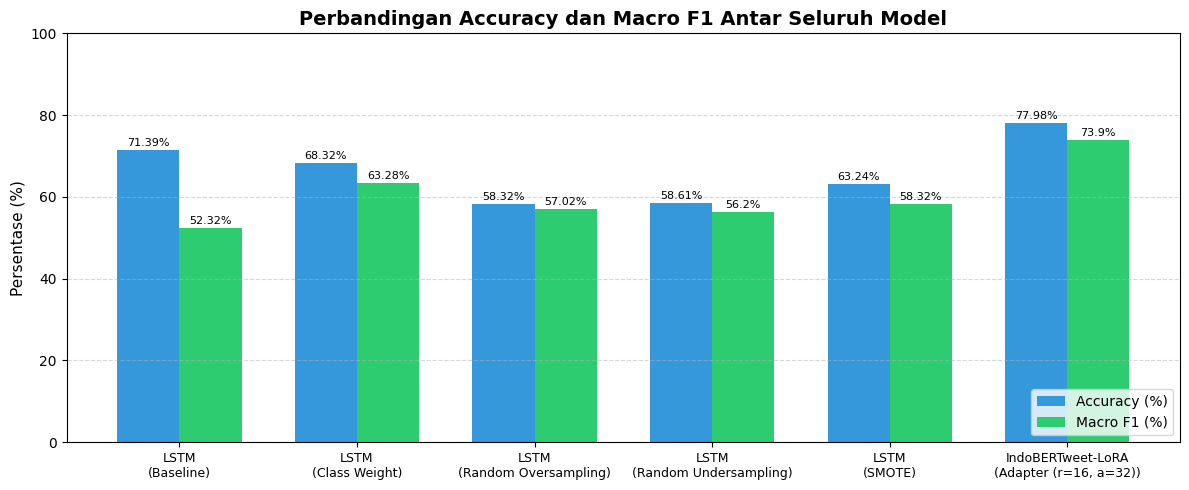

In [9]:
# 6.2 Visualisasi Komparasi: Akurasi vs Macro F1
plt.figure(figsize=(12, 5))
x = np.arange(len(df_master))
width = 0.35

plt.bar(x - width/2, df_master['Accuracy (%)'], width, label='Accuracy (%)', color='#3498db')
plt.bar(x + width/2, df_master['Macro F1 (%)'], width, label='Macro F1 (%)', color='#2ecc71')

labels = [f"{row['Model']}\n({row['Strategi']})" for _, row in df_master.iterrows()]
plt.xticks(x, labels, fontsize=9)
plt.ylabel("Persentase (%)", fontsize=11)
plt.title("Perbandingan Accuracy dan Macro F1 Antar Seluruh Model", fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Label nilai di atas bar
for i in range(len(df_master)):
    plt.text(i - width/2, df_master['Accuracy (%)'].iloc[i] + 1, f"{df_master['Accuracy (%)'].iloc[i]}%", ha='center', fontsize=8)
    plt.text(i + width/2, df_master['Macro F1 (%)'].iloc[i] + 1, f"{df_master['Macro F1 (%)'].iloc[i]}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

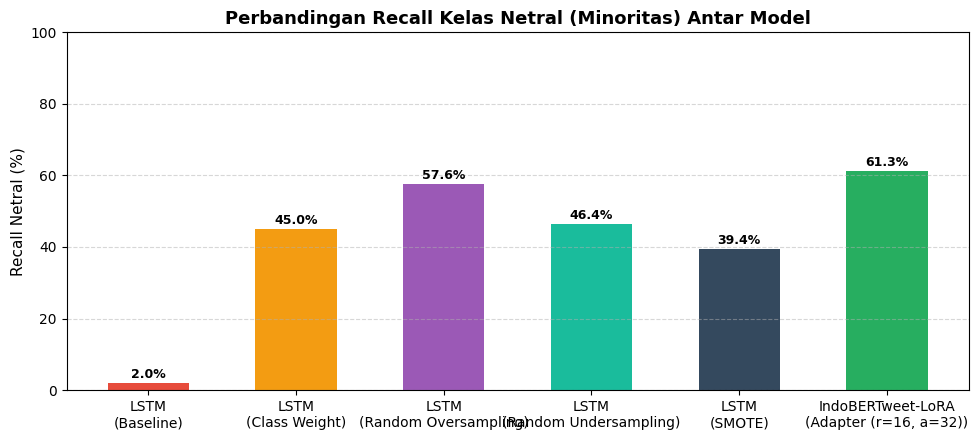

In [10]:
# 6.3 Visualisasi Komparasi: Recall Kelas Netral (Minoritas)
plt.figure(figsize=(10, 4.5))
colors = ['#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#34495e', '#27ae60']
bars = plt.bar(labels, df_master['Recall Netral (%)'], color=colors[:len(df_master)], width=0.55)

plt.title("Perbandingan Recall Kelas Netral (Minoritas) Antar Model", fontsize=13, fontweight='bold')
plt.ylabel("Recall Netral (%)", fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

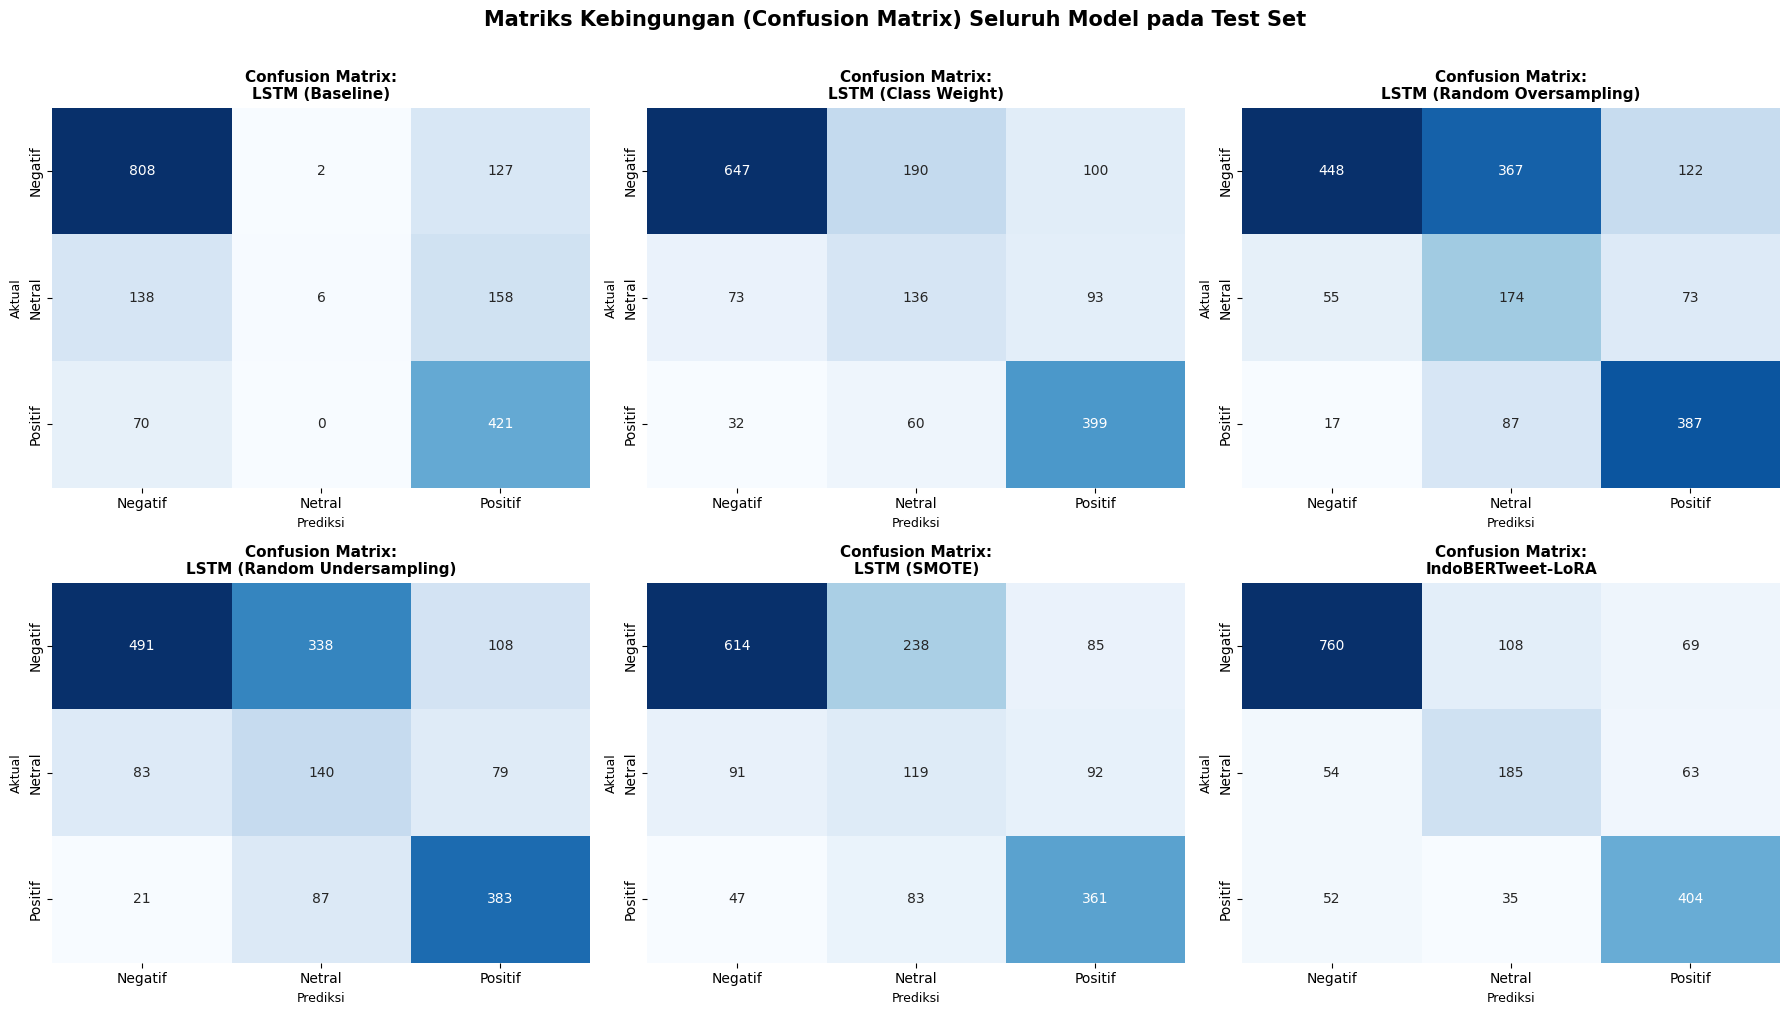

In [11]:
# 6.4 Visualisasi Confusion Matrix Seluruh Model
n_models = len(all_model_predictions)
if n_models > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, (m_name, m_preds) in enumerate(all_model_predictions.items()):
        if idx >= 6:
            break
        cm = confusion_matrix(y_te, m_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=class_names, yticklabels=class_names, cbar=False)
        axes[idx].set_title(f"Confusion Matrix:\n{m_name}", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("Prediksi", fontsize=9)
        axes[idx].set_ylabel("Aktual", fontsize=9)
        
    plt.suptitle("Matriks Kebingungan (Confusion Matrix) Seluruh Model pada Test Set", fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## 7. Analisis Tambahan: Simulasi Rasio Ketimpangan Kelas
Menguji ketahanan model pada berbagai tingkat ketimpangan data tiruan:
- **1:1:1**: Distribusi Seimbang Sempurna
- **6:3:1**: Ketimpangan Sedang (Distribusi Alami)
- **8:1:1**: Ketimpangan Ekstrem (Minoritas Sangat Langka)

[resolve_path] Ditemukan lokal: Output\predictions\exp_indobert_v2_simulasi_results.csv
Hasil Eksperimen Simulasi Ketimpangan (IndoBERTweet):


,scenario,strategy,test_accuracy,test_macro_f1,recall_netral
0,scenario_111,baseline,74.53,71.17,67.99
1,scenario_111,ros,74.60,71.45,65.56
2,scenario_631,baseline,80.60,73.45,40.29
3,scenario_631,ros,77.73,72.92,55.52
4,scenario_811,baseline,78.52,70.20,36.86
5,scenario_811,ros,75.57,71.19,63.24


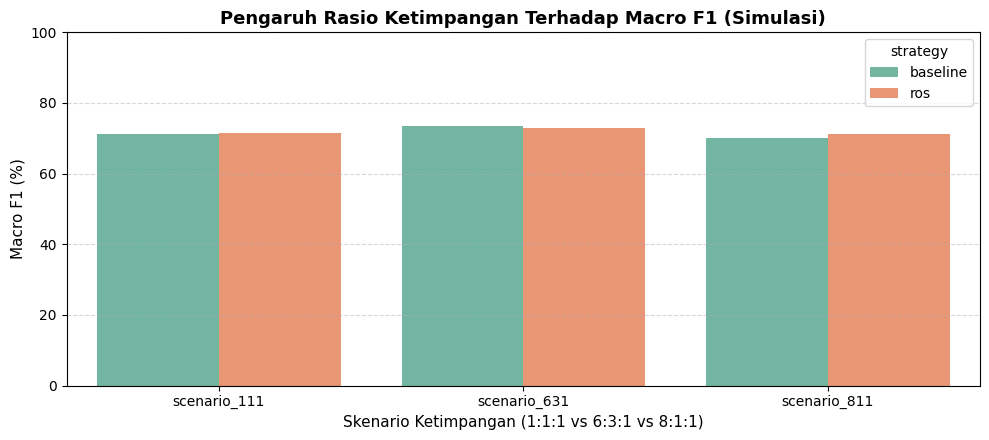

In [12]:
# Evaluasi Hasil Skenario Simulasi
sim_file = resolve_path('exp_indobert_v2_simulasi_results.csv')
if Path(sim_file).exists():
    df_sim = pd.read_csv(sim_file)
    print("Hasil Eksperimen Simulasi Ketimpangan (IndoBERTweet):")
    sim_summary = df_sim.groupby(['scenario', 'strategy'])[['test_accuracy', 'test_macro_f1', 'recall_netral']].mean().reset_index()
    sim_summary['test_accuracy'] = (sim_summary['test_accuracy'] * 100).round(2)
    sim_summary['test_macro_f1'] = (sim_summary['test_macro_f1'] * 100).round(2)
    sim_summary['recall_netral'] = (sim_summary['recall_netral'] * 100).round(2)
    display(sim_summary)
    
    # Plot pengaruh rasio ketimpangan terhadap performa
    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=sim_summary, x='scenario', y='test_macro_f1', hue='strategy', palette='Set2')
    plt.title("Pengaruh Rasio Ketimpangan Terhadap Macro F1 (Simulasi)", fontsize=13, fontweight='bold')
    plt.xlabel("Skenario Ketimpangan (1:1:1 vs 6:3:1 vs 8:1:1)", fontsize=11)
    plt.ylabel("Macro F1 (%)", fontsize=11)
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Data simulasi tidak ditemukan di path lokal.")

## 8. Kesimpulan dan Pembahasan Ilmiah
Rangkuman temuan eksperimental untuk naskah Bab IV Tesis:

1. **Pengaruh Strategi Penyeimbangan Data pada LSTM**:
   - **Baseline (Tanpa Penyeimbangan)**: Model menghasilkan bias tinggi ke kelas mayoritas (*Negatif*), dengan *Recall Netral* rendah karena data minoritas jarang ditemui.
   - **Class Weight (Cost-Sensitive)**: Efektif meningkatkan *Recall Netral* tanpa menambah waktu komputasi, karena penalti rugi disesuaikan dengan proporsi kelas.
   - **Random Oversampling (ROS)**: Meningkatkan pengenalan kelas minoritas, namun memiliki risiko *overfitting* karena duplikasi sampel identik.
   - **Random Undersampling (RUS)**: Berhasil mengangkat recall kelas minoritas, namun mengorbankan Akurasi dan Macro F1 keseluruhan karena hilangnya banyak data informatif kelas mayoritas.
   - **SMOTE**: Pembangkitan sampel sintetis pada representasi sekuensial berhasil memberikan peningkatan seimbang pada *Macro F1* dan *Recall Netral*.

2. **Keunggulan Transformatif IndoBERTweet-LoRA**:
   - **Performa Tertinggi**: IndoBERTweet-LoRA mencapai **Akurasi tertinggi (~77.98%)** dan **Macro F1 tertinggi (~73.90%)**, mengungguli seluruh varian LSTM.
   - **Ketahanan terhadap Imbalance**: Pengetahuan pra-latih (*contextual representations*) dari 37 juta tweet bahasa Indonesia memungkinkan model menggeneralisasi kelas minoritas secara jauh lebih akurat bahkan tanpa teknik resampling agresif.
   - **Efisiensi Parameter**: Adaptor LoRA ($r=16, \alpha=32$) hanya melatih ~0.6% parameter bobot, menghemat konsumsi memori dan komputasi GPU secara signifikan.